<a href="https://colab.research.google.com/github/Faisalt28/Clustering-Social-Media-Addictive-Level/blob/main/Clustering_Addictive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

# Download latest version
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/social-media-addiction-vs-relationships


In [ ]:
df = pd.read_csv(path + "/Students Social Media Addiction.csv")
print("Lima baris pertama dari dataset")
df.head()

Lima baris pertama dari dataset


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

# EKSPLORASI & PERSIAPAN DATA

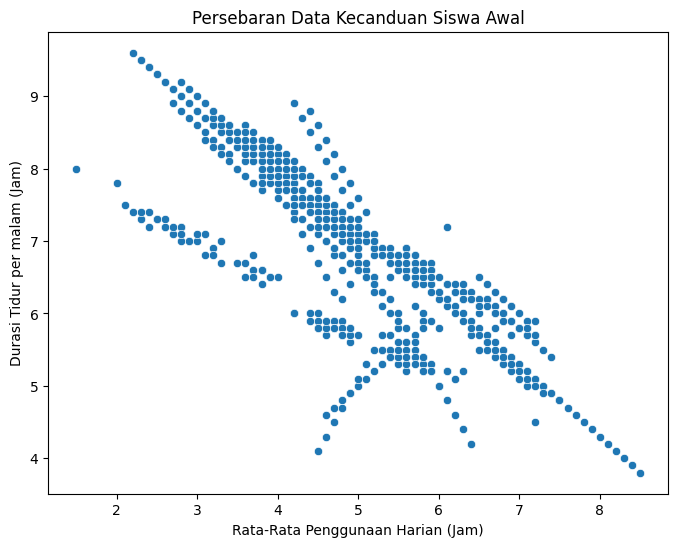

In [ ]:
X = df.loc[:, ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']].values

#Lihat persebaran data
plt.figure(figsize=(8,6))
sns.scatterplot(x=X[:,0], y=X[:,1])
plt.title('Persebaran Data Kecanduan Siswa Awal')
plt.xlabel('Rata-Rata Penggunaan Harian (Jam)')
plt.ylabel('Durasi Tidur per malam (Jam)')
plt.show()

In [ ]:
#Normalisasi

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# MENENTUKAN JUMLAH CLUSTER OPTIMAL (ELBOW METHOD)

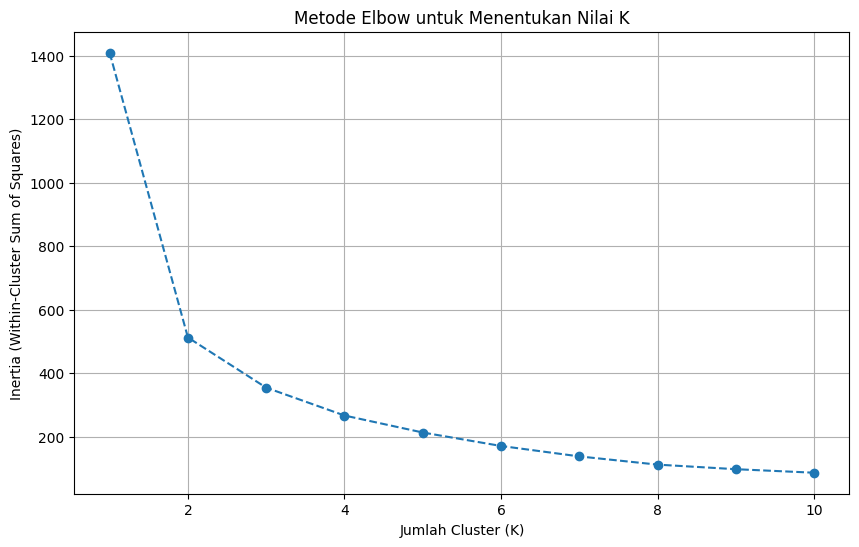

In [ ]:
# Menentukan nilai K optimal dengan Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


# Plot Elbow
plt.figure(figsize=(10,6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Nilai K')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# MELATIH MODEL K-MEANS & VISUALISASI HASIL


Model K-Means dengan K=3 telah dilatih.
Label cluster untuk 5 data pertama: [2 0 1 0 2]


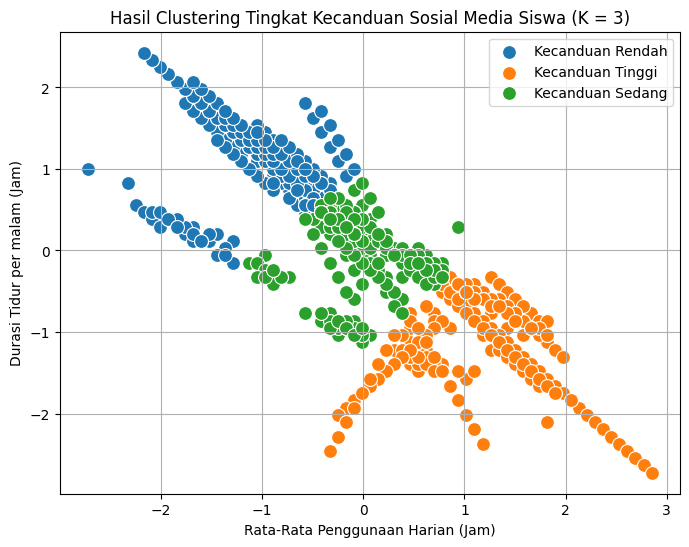


Jumlah siswa per tingkat kecanduan:
Label_Kecanduan
Kecanduan Sedang    258
Kecanduan Rendah    236
Kecanduan Tinggi    211
Name: count, dtype: int64

Contoh data dengan label:
   Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night   Label_Kecanduan
0                    5.2                    6.5  Kecanduan Sedang
1                    2.1                    7.5  Kecanduan Rendah
2                    6.0                    5.0  Kecanduan Tinggi
3                    3.0                    7.0  Kecanduan Rendah
4                    4.5                    6.0  Kecanduan Sedang


In [ ]:
# Latih model dengan K=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)

# Latih model dan prediksi cluster untuk setiap data point
y_kmeans = kmeans.fit_predict(X_scaled)

print(f"\nModel K-Means dengan K={k_optimal} telah dilatih.")
print("Label cluster untuk 5 data pertama:", y_kmeans[:5])

# Tambahkan hasil cluster ke dataframe
df['Cluster'] = y_kmeans

# ----------------------------
# Fungsi visualisasi otomatis
# ----------------------------
def label_clusters_by_addiction_level_flexible(X, y_kmeans, kmeans_model):
    # Hitung pusat klaster
    centroids = kmeans_model.cluster_centers_

    # Hitung skor kecanduan: lebih tinggi penggunaan, lebih rendah tidur = lebih kecanduan
    addiction_scores = centroids[:, 0] - centroids[:, 1]
    sorted_indices = np.argsort(addiction_scores)[::-1]  # Urutkan dari yang paling kecanduan

    # Label khusus untuk K=3
    base_label = "Kecanduan"
    level_labels = [
        f"{base_label} Tinggi",
        f"{base_label} Sedang",
        f"{base_label} Rendah"
    ]

    # Mapping cluster index ke label
    cluster_label_map = {sorted_indices[i]: level_labels[i] for i in range(3)}

    # Tambahkan label ke dataframe
    df['Label_Kecanduan'] = df['Cluster'].map(cluster_label_map)

    # Visualisasi
    plt.figure(figsize=(8,6))
    for cluster_index in range(3):
        cluster_points = X_scaled[y_kmeans == cluster_index]
        sns.scatterplot(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            s=100,
            label=cluster_label_map[cluster_index]
        )

    plt.title('Hasil Clustering Tingkat Kecanduan Sosial Media Siswa (K = 3)')
    plt.xlabel('Rata-Rata Penggunaan Harian (Jam)')
    plt.ylabel('Durasi Tidur per malam (Jam)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return cluster_label_map

# ---------------------------------------
# Jalankan fungsi visualisasi & labeling
# ---------------------------------------
cluster_label_map = label_clusters_by_addiction_level_flexible(X, y_kmeans, kmeans)

# --------------------------------------
# (Opsional) Ringkasan hasil clustering
# --------------------------------------
print("\nJumlah siswa per tingkat kecanduan:")
print(df['Label_Kecanduan'].value_counts())

print("\nContoh data dengan label:")
print(df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Label_Kecanduan']].head())


# MENYIMPAN MODEL UNTUK DEPLOYMENT

In [ ]:
file_model = 'uas_ml_addictive.pkl'

# Simpan model dan scaler dalam satu dictionary
model_bundle = {
    'scaler': scaler,     # StandardScaler yang sudah fit
    'model': kmeans       # Model KMeans yang sudah fit
}

# Simpan ke file
with open(file_model, 'wb') as file:
    pickle.dump(model_bundle, file)

print(f"\Model '{file_model}' telah disimpan!")
print("Siap dideploy")

\Model 'uas_ml_addictive.pkl' telah disimpan!
Siap dideploy
